# Platform & Workspace

We explore the Databricks Lakehouse platform — architecture, workspace components, compute types, and the basics of Unity Catalog. We also cover **cost management** principles and learn to work efficiently with the **Databricks GUI**: notebooks, markdown, mixing SQL and Python, simple visualizations, and the AI Assistant.

## Learning Objectives

After completing this module you will be able to:

- **Describe** the Databricks Lakehouse architecture — how it combines Data Lake and Data Warehouse benefits
- **Navigate** the Databricks workspace: notebooks, clusters, DBFS, Catalog Explorer, Git Folders
- **Explain** the difference between All-Purpose clusters and Job clusters and their cost implications
- **Understand** autoscaling and how it impacts costs
- **Apply** basic cost management principles: choosing the right cluster type, sizing, auto-termination
- **Use** the GUI effectively: write markdown, mix SQL and Python in the same notebook
- **Create** simple visualizations directly in the notebook GUI
- **Understand** how the Databricks AI Assistant supports daily work in notebooks
- **Describe** Unity Catalog's 3-level namespace: `catalog.schema.table`


## Databricks Platform Elements

Key elements of the Databricks platform: Workspace, Catalog Explorer, Git Folders, Volumes. Understanding the platform structure is the foundation of a Data Engineer's work.

---

### Per-user Isolation

Run the initialization script for per-user catalog and schema isolation:


In [0]:
%run ../../setup/00_setup

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.types import *
import re

# Display user context (variables from 00_setup)
print(f"Catalog: {CATALOG}")
print(f"Schema Bronze: {BRONZE_SCHEMA}")
print(f"Schema Silver: {SILVER_SCHEMA}")
print(f"Schema Gold: {GOLD_SCHEMA}")
print(f"User: {raw_user}")

### Comparison of Traditional Architecture vs Lakehouse

**Objective:** Visualize differences between traditional approach (Data Lake + Data Warehouse) and Lakehouse.

![alt text](../../../assets/images/4c9090bd82f2475c810bafde13f978e0.png)

**Traditional Architecture:**

<img src="../../../assets/images/49f3830d3784442ea5582bc82e6fb89c.png" width="800">

**Lakehouse Benefits:**
- Single copy of data (single source of truth)
- Lower storage costs
- Elimination of synchronization latency
- Common governance for all use cases

### Key Components

**Theoretical Introduction:**

The Databricks platform consists of several key components that together create a complete environment for working with data in the Lakehouse architecture.

**Key Components:**
- **Workspace**: Working environment containing notebooks, experiments, folders, and resources
- **Catalog Explorer**: Interface for managing catalogs, schemas, tables, and views
- **Git Folders (formerly Repos)**: Git integration for versioning notebooks and code
- **Volumes**: Management of unstructured files (images, models, artifacts)
- **DBFS (Databricks File System)** *(legacy — use Volumes instead)*: Virtual file system over cloud storage

**Practical Application:**
- Workspace organizes projects and team collaboration
- Catalog Explorer enables data exploration and governance
- Git Folders integrates development workflow with Git

### Workspace Exploration

#### Example: Workspace Exploration

**Objective:** Familiarize with Databricks Workspace interface

**Workspace Elements:**
1. **Sidebar** (left side):
   - Workspace: Folders and notebooks
   - Git Folders: Git Integration
   - Compute: Cluster management
   - Workflows: Lakeflow Jobs
   - Catalog: Unity Catalog explorer

2. **Main Panel**: Notebook editor or details view

3. **Top Bar**: Quick access to compute, account, help

**Navigation Instructions:**
- Use the left menu to switch between sections
- In the Catalog section, you can browse catalogs, schemas, and tables
- In the Compute section, you manage Spark clusters

#### Databricks Workspace UI

<img src="../../../assets/images/848bc3658ab44bb09f586bd2b1f4231e.png" width="800">

### Catalog Explorer - Unity Catalog Structure

#### Example: Catalog Explorer

**Objective:** Understand object hierarchy in Unity Catalog

#### Catalog Explorer Screenshot

<img src="../../../assets/images/32356ba877a74bfe87feeb6d6ee93a46.png" width="800">


In [0]:
# Display current catalog and schema
current_catalog = spark.sql("SELECT current_catalog()").collect()[0][0]
current_schema = spark.sql("SELECT current_schema()").collect()[0][0]

print(f"Current catalog: {current_catalog}")
print(f"Current schema: {current_schema}")

**Unity Catalog Hierarchy:**

<img src="../../../assets/images/cddc09f5ffc5482aa3063a13a7c4f927.png" width="800">

> **3-level namespace:** `catalog.schema.object` — e.g., `prod.gold.sales_summary`

### Browsing Catalogs and Schemas

#### Example: Browsing Catalogs and Schemas

**Objective:** Programmatic listing of objects in Unity Catalog

In [0]:
# List of all catalogs available to the user
catalogs_df = spark.sql("SHOW CATALOGS")
display(catalogs_df)

In [0]:
# List of schemas in the current catalog
schemas_df = spark.sql(f"SHOW SCHEMAS IN {CATALOG}")
display(schemas_df)

### Git Folders

In production, notebooks live in **Git Folders** (Repos) — version-controlled via GitHub/GitLab/Azure DevOps.

Key workflow: **Feature branch → Pull Request → Merge → Databricks Asset Bundle deploy**.

Covered in detail in `09_cicd_and_automation`.


### Volumes vs DBFS

Where should you store files? In new Unity Catalog-based workspaces, **Volumes** are the preferred location.

- `dbfs:/` is treated as a **legacy** layer or auxiliary area.
- `/Volumes/catalog.schema.volume_name` is a fully managed, UC-controlled data area (permissions, audit, lineage).

Volume Definition Example (SQL):

```sql
CREATE VOLUME IF NOT EXISTS ${catalog}.${schema}.training_volume
COMMENT 'Workspace for training purposes';
```

Usage Example in PySpark:

```python
catalog = dbutils.widgets.get("catalog")
schema = dbutils.widgets.get("schema")

volume_path = f"/Volumes/{catalog}/{schema}/training_volume"
display(dbutils.fs.ls(volume_path))
```

## Compute Resources

Types of compute resources in Databricks: All-Purpose Clusters, Job Clusters, SQL Warehouses. Choosing the right compute directly impacts costs.

---

### The Real Question: How Much Will This Cost?

As a Data Engineer, you'll be asked: *"Why is our Databricks bill so high?"*

Understanding compute options is essential for cost control.

### Compute Options Comparison

| Type | Startup Time | Cost Model | Best For |
|------|--------------|------------|----------|
| **All-Purpose Cluster** | 3-5 min | Per-minute (running) | Interactive development, exploration |
| **Job Cluster** | 3-5 min | Per-minute (only during job) | Scheduled production jobs |
| **Serverless** | <10 sec | Per-query DBUs | Ad-hoc queries, variable workloads |
| **SQL Warehouse** | 0 (Serverless) or 3-5 min | Per-query DBUs | BI tools, SQL analysts |

### Cost Optimization Strategies

**1. Right-size clusters:**
- Development: 2-4 workers, smallest instance type
- Production: Autoscaling 2-10 workers based on workload

**2. Use Spot/Preemptible instances:**
- 60-80% cost savings for workers
- Driver on on-demand (stability)
- Trade-off: Job may be interrupted

**3. Photon Engine:**
- 2-3x faster for aggregations/joins
- ~2x DBU cost, but finishes faster = often cheaper
- Enable for: large scans, aggregations, joins
- Skip for: simple transformations, ML training

**4. Cluster policies:**
- Enforce maximum worker count
- Require autoscaling
- Set auto-termination (e.g., 30 min idle)

### Decision Tree: Which Compute to Use?

<img src="../../../assets/images/f98e20f71ec541eb9b206877f1da98b5.png" width="800">

---

---
### Serverless Compute — the new default in Databricks

> **Since 2024, Serverless is the default compute type** for new notebooks and jobs in most regions.

**What is Serverless?**
- Databricks manages the infrastructure — **you don't need to configure a cluster**
- Starts in **< 10 seconds** (vs 3-5 minutes for a classic cluster)
- You pay only for actually consumed resources (seconds of execution, not cluster uptime)
- Automatic resource scaling in the background — invisible to the user

**Serverless models in Databricks:**

| Context | Serverless compute |
|----------|-------------------|
| Notebooks (Serverless clusters) | Cluster starts in < 10s, stops when the session ends |
| Workflow Jobs (Serverless jobs) | Each run = its own isolated compute |
| SQL Warehouse (Serverless) | Fastest type — dedicated to SQL / BI |
| Delta Live Tables (Serverless) | DLT pipelines without managing compute |

**When NOT to use Serverless?**
- Large ML workloads with GPU (e.g., model fine-tuning) — a dedicated cluster with GPU is needed here
- Workloads requiring specific libraries installed at system level (custom init scripts)
- Extremely large shuffles (100+ GB) — a classic cluster may be more efficient

> **How to enable Serverless for a notebook:** In the top-right corner, select "Connect to compute" → "Serverless"


### SQL Warehouse

A SQL engine optimized for BI and ad-hoc analytics, an alternative to notebook clusters.

When to use:
- Reporting in Power BI / other BI tools.
- Business analysts / power users working mainly in SQL.
- Interactive dashboards and ad-hoc queries to **Gold** layer.

Differences from all-purpose cluster:
- Billing based on **DBU SQL** (different rates).
- Automatic provisioning / scaling.
- Isolation of BI workload from engineering clusters.

---

---
### SQL Warehouse — dedicated compute for SQL and BI

**SQL Warehouse** is a separate compute type, decoupled from notebook clusters. Designed specifically for:
- Analysts using the SQL Editor
- BI tools: Tableau, Power BI, Looker
- AI/BI Dashboards and Genie in Databricks

**SQL Warehouse types:**

| Type | Startup | Cost | When to use |
|------|---------|------|------------|
| **Serverless** | < 3 sec | Higher DBU/hr, but only query time | Interactive SQL work, variable workloads |
| **Pro** | 3-5 min | Medium, rich features | Ad-hoc analytics, advanced workloads |
| **Classic** | 3-5 min | Lowest, basic features | Simple SQL queries, CI/CD query testing |

**How to create a SQL Warehouse:**
1. Left menu → **SQL Warehouses**
2. Click **Create SQL Warehouse**
3. Choose type: **Serverless** (recommended for training)
4. Cluster Size: `X-Small` (sufficient for demo)
5. Auto Stop: `10 minutes` (cost savings)

**How to connect Power BI / Tableau:**
1. Click your SQL Warehouse → **Connection details** tab
2. Copy **Server hostname** and **HTTP path**
3. In Power BI: Get Data → Azure → Azure Databricks
4. Paste Server hostname + HTTP path → sign in via Azure AD

> **Key difference:** Notebook cluster = for Data Engineers (Python/PySpark/Scala).  
> SQL Warehouse = for SQL Analysts and BI Tools. Do not attach a notebook to a SQL Warehouse!


## Compute Types in Databricks

### All-purpose Cluster (Shared / Interactive)

| Property | Value |
|---|---|
| Start | Manual (or auto-start) |
| Lifetime | Long-running — stays up until stopped |
| Users | Multiple simultaneous (shared cluster) |
| Cost | Billed for the entire uptime |
| Typical use | Data exploration, development, debugging |

```python
# Working on an all-purpose cluster — just use a notebook
spark.read.table("bronze.orders").display()
```

### Job Cluster (Automated / Ephemeral)

| Property | Value |
|---|---|
| Start | Automatic — spun up for the job only |
| Lifetime | Short-lived — terminated when the job finishes |
| Users | 1 job = 1 cluster |
| Cost | Billed only during job execution |
| Typical use | Production pipelines, DLT, scheduled jobs |

> **Best practice:** always run production pipelines on a Job Cluster — cheaper and isolated.

### SQL Warehouse (for analysts and BI)

| Property | Value |
|---|---|
| Start | Automatic (auto-start on first query) |
| Protocol | JDBC/ODBC — compatible with any BI tool |
| Users | Multiple simultaneous (auto-scale) |
| Cost | Billed only during active use (auto-stop on idle) |
| Typical use | Power BI, Tableau, Looker, Databricks SQL Editor |

> **Key difference:** SQL Warehouse is **optimised for SQL**, not PySpark. It uses the Photon engine by default.

### Serverless Compute

A variant of both all-purpose and SQL Warehouse — no infrastructure management, instant start, Databricks manages the entire fleet. Higher per-DBU cost, but zero operational overhead.

## When to Use Which Compute?

| Task | Compute | Why |
|---|---|---|
| Data exploration in a notebook | **All-purpose Cluster** | Interactive, PySpark, iterative |
| Production ETL pipeline | **Job Cluster** | Ephemeral, isolated, cheaper |
| Lakeflow / DLT pipeline | **Job Cluster** (auto) | DLT manages it automatically |
| SQL query for analysis | **SQL Warehouse** | Optimised SQL, auto-scale |
| Power BI / Tableau dashboard | **SQL Warehouse** | JDBC/ODBC, certified connector |
| Ad-hoc analyst query | **SQL Warehouse** | Fast start, no Spark overhead |
| ML training | **All-purpose / Job** | GPU support, MLflow integration |


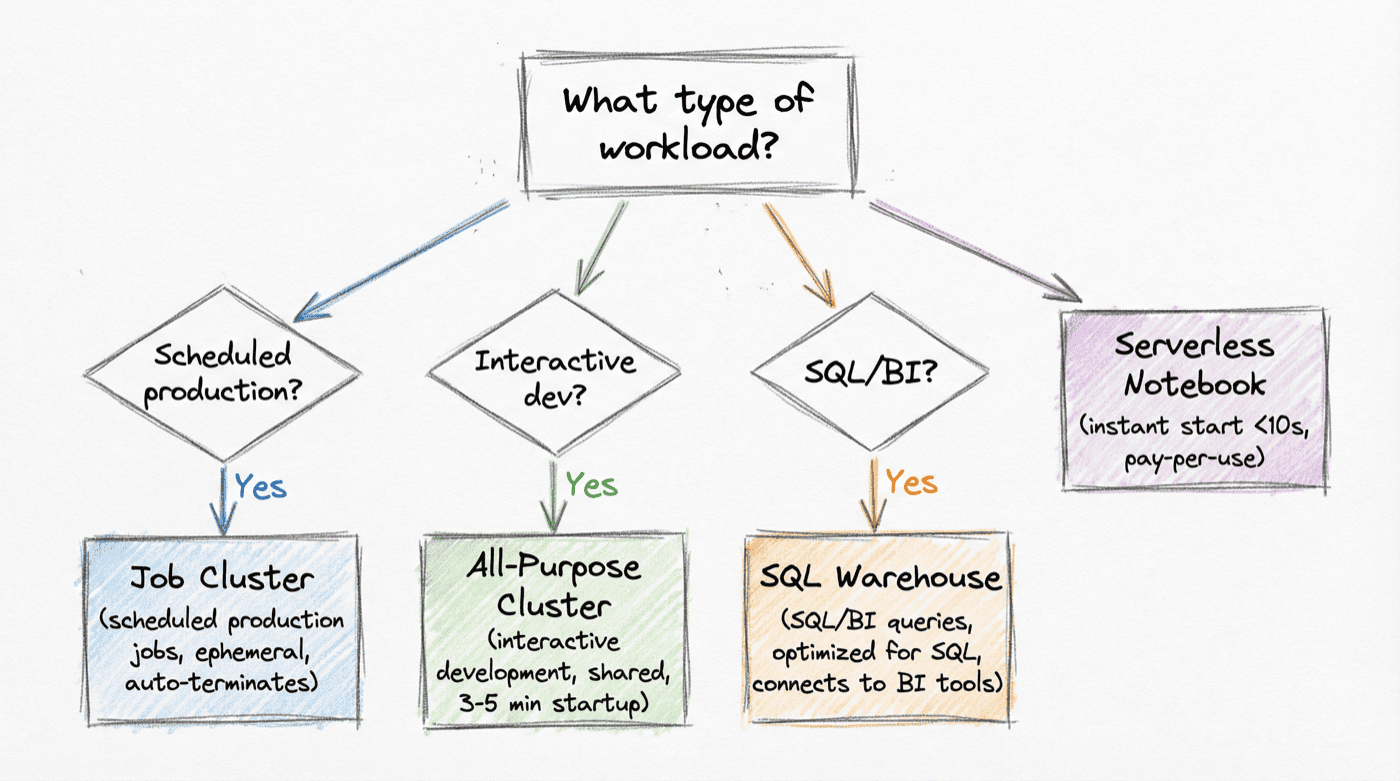

> **Simple rule:**
> - **writing code (Python / Scala / PySpark)** → cluster
> - **doing SQL analytics or BI** → SQL Warehouse

### Cluster Info

Check the runtime version and Photon status on the current cluster.

In [0]:
# Cluster runtime and Photon status
dbr_version = spark.conf.get("spark.databricks.clusterUsageTags.sparkVersion", "unknown")
photon = spark.conf.get("spark.databricks.photon.enabled", "false")
print(f"Runtime: {dbr_version}  |  Photon: {photon}")

### Monitoring

Where to look for problems: **Cluster → Event log** | **Spark UI** (Jobs, SQL tabs) | **Driver/Executor logs**

> **Best Practice:** For production pipelines, log to Delta tables — not just cluster logs.

## Magic Commands

Magic commands allow you to switch between languages and perform system operations directly from notebook cells.

---

| Command | Purpose |
|---------|---------|
| `%sql` | SQL cell |
| `%python` | Python cell (default) |
| `%md` | Markdown documentation |
| `%fs` | DBFS file operations |
| `%sh` | Shell commands |
| `%run` | Execute another notebook |
| `%pip` | Install notebook-scoped libraries |

---

### Commenting / Uncommenting Lines

| Action | Mac | Windows / Linux |
|--------|-----|-----------------|
| Toggle comment on selected lines | `Cmd + /` | `Ctrl + /` |


### Demo: Quick Data Analysis

`dbutils.data.summarize()` generates rich column-level statistics — nulls, min/max, distinct count, value distribution — without leaving the notebook.


In [ ]:
# dbutils.data.summarize() — column-level statistics in one call
# Works on any DataFrame or Delta table: nulls, min/max, distinct count, distribution

df_sales = spark.table(table_name)
dbutils.data.summarize(df_sales)

### Demo: %sql

In [0]:
%sql
-- SQL magic command allows writing pure SQL without Python wrapper

SELECT 
  current_catalog() as catalog,
  current_schema() as schema,
  current_user() as user,
  current_timestamp() as timestamp

### Demo: Mixing Python + SQL

Create data in Python → query with SQL via temp view:

In [0]:
# Python: Raw data definition
data = [
    (1, "Alice", "Engineering", 95000),
    (2, "Bob", "Sales", 75000),
    (3, "Charlie", "Engineering", 105000),
    (4, "Diana", "Marketing", 68000),
    (5, "Eve", "Engineering", 98000)
]

# Schema definition
schema = StructType([
    StructField("id", IntegerType(), False),
    StructField("name", StringType(), False),
    StructField("department", StringType(), False),
    StructField("salary", IntegerType(), False)
])

In [0]:
# Create DataFrame
df = spark.createDataFrame(data, schema)
display(df)

In [0]:
# Register as temp view for SQL access
df.createOrReplaceTempView("employees_temp")

In [0]:
%sql
-- SQL: Aggregation on Python data

SELECT 
  department,
  COUNT(*) as employee_count,
  AVG(salary) as avg_salary,
  MAX(salary) as max_salary
FROM employees_temp
GROUP BY department
ORDER BY avg_salary DESC

### Databricks Assistant (AI)

In 2025, coding work is assisted by AI. Databricks has a built-in assistant (**Databricks Assistant**) that is context-aware of your data (knows table schemas in Unity Catalog!).

**How to use?**
1. Shortcut **Cmd+I** (Mac) or **Ctrl+I** (Windows) inside a cell.
2. "Assistant" side panel.

**What is it for?**
- **Code Generation**: "Write a SQL query that calculates average sales by region from the sales table".
- **Code Explanation**: Select a complex snippet and ask "Explain this code".
- **Fixing errors**: When a cell returns an error, click "Diagnose Error" – the assistant will explain the cause and propose a fix.
- **Transformation**: "Rewrite this code from PySpark to SQL".

---

## Unity Catalog

A modern metadata management system replacing Hive Metastore. Provides centralized access control, lineage, and governance across the entire organization.

---

### Theoretical Introduction

Databricks supports two metadata systems: legacy Hive Metastore and modern Unity Catalog. Unity Catalog is recommended for all new projects due to advanced governance and security features.

**Key Differences:**

| Aspect | Hive Metastore | Unity Catalog |
|--------|----------------|---------------|
| **Governance** | Limited | Full: RBAC, masking, audit |
| **Namespace** | 2-level (db.table) | 3-level (catalog.schema.table) |
| **Cross-workspace** | No | Yes (shared metastore) |
| **Lineage** | None | End-to-end lineage |
| **Data Sharing** | Limited | Delta Sharing protocol |
| **Isolation** | Workspace-level | Catalog-level |

**Why Unity Catalog?**
- Central access management for all workspaces
- Automatic lineage for audit and compliance
- Fine-grained permissions (column-level, row-level)
- Integration with external systems (Delta Sharing)

### Creating a Table in Unity Catalog

#### Example: Creating a Table

**Objective:** Demonstrate full syntax with 3-level namespace

In [0]:
# Table name in Unity Catalog (3-level namespace)
table_name = f"{CATALOG}.{BRONZE_SCHEMA}.retail_sales"

# Sales dataset: 5 regions × 4 categories — good for visualizations
sales_data = [
    ("North",   "Electronics",  142500, 1180, 120.76),
    ("North",   "Apparel",       58300,  940,  62.02),
    ("North",   "Food",          34200,  870,  39.31),
    ("North",   "Home",          71400,  620, 115.16),
    ("South",   "Electronics",   98700,  820, 120.37),
    ("South",   "Apparel",       45100,  730,  61.78),
    ("South",   "Food",          61800, 1540,  40.13),
    ("South",   "Home",          53200,  470, 113.19),
    ("East",    "Electronics",  175300, 1450, 120.90),
    ("East",    "Apparel",       67900, 1090,  62.29),
    ("East",    "Food",          48500, 1210,  40.08),
    ("East",    "Home",          89100,  780, 114.23),
    ("West",    "Electronics",  210400, 1740, 120.92),
    ("West",    "Apparel",       82600, 1330,  62.11),
    ("West",    "Food",          55900, 1380,  40.51),
    ("West",    "Home",         103700,  910, 113.96),
    ("Central", "Electronics",   76300,  630, 121.11),
    ("Central", "Apparel",       31400,  510,  61.57),
    ("Central", "Food",          28700,  710,  40.42),
    ("Central", "Home",          42800,  380, 112.63),
]

In [0]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType

sales_schema = StructType([
    StructField("region",          StringType(),  False),
    StructField("category",        StringType(),  False),
    StructField("revenue",         IntegerType(), False),
    StructField("transactions",    IntegerType(), False),
    StructField("avg_order_value", DoubleType(),  False),
])

sales_df = spark.createDataFrame(sales_data, sales_schema)
display(sales_df)

In [0]:
# Save as Delta Table in Unity Catalog (3-level namespace)
sales_df.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(table_name)

print(f"Table saved: {table_name}")

In [0]:
# Read back from Delta — verification
display(spark.table(table_name))

### Data Profiling (no code!)

Databricks automatically generates a **data profile** — summary statistics for every column.

#### How to do it:
1. Run the cell below with `display(df)` on the full table
2. In the result widget, click **`+`** → **Data Profile**
3. View: min/max, null counts, value distribution per column

> **Useful before analysis** — quickly spot nulls, outliers, unexpected distributions.

In [0]:
# Full table — click "+" → Data Profile to see statistics for all columns
display(spark.table(table_name))

### Comparison PySpark vs SQL

**DataFrame API (PySpark):**

In [0]:
# PySpark Approach - programmatic DataFrame API
df_pyspark = spark.table(table_name)

In [0]:
result_pyspark = df_pyspark \
    .filter(F.col("region") == "West") \
    .select("region", "category", "revenue", "transactions") \
    .orderBy(F.desc("revenue"))
display(result_pyspark)

**SQL Equivalent:**

In [0]:
df = spark.sql(f"SELECT * FROM {table_name} WHERE region = 'West'")
display(df)

**Comparison:**
- **Performance**: Identical - both approaches compile to the same Catalyst query plan
- **When to use PySpark**: 
  - Complex business logic with UDFs
  - Dynamic pipelines (parameterization, loops)
  - Integration with Python libraries (pandas, scikit-learn)
- **When to use SQL**: 
  - Simple transformations and aggregations
  - Team with strong SQL skills
  - Migration from traditional Data Warehouse
  - Better support for business analysts

---

## Spark Architecture


---
## 1. Driver & Executors — cluster architecture

When you run a cell in a notebook, Databricks does not execute it on your laptop. The code goes to a **Spark cluster**, which consists of:

<img src="../../../assets/images/5ea7056c932f4759afa86902f27317fe.png" width="860">

### Driver
- One process per cluster — coordinates all work
- Holds `SparkSession`, builds the query plan, schedules tasks
- If the Driver crashes → the job crashes
- **Your Python code runs on the Driver** — loops, list comprehensions, `print()` — all on the Driver

### Executors
- Many processes on worker nodes — perform the actual computation
- Each Executor processes one or more **partitions** in parallel
- Results return to the Driver (e.g., with `collect()`) or are written to storage

### Partition — unit of parallelism
Data in Spark is divided into **partitions** (~128 MB each). One partition = one task on one core of one Executor.

![Spark Partitions](../../../assets/images/9b9d5e3d62aa41119f758b11ea5a1c60.png)

> **Key principle:** Spark does not move data to the computation — it moves small code to where the data is (data locality). That is why it scales to petabytes.


---
## 2. Lazy Evaluation — code that doesn't run immediately

This is **the most important concept in Spark** and the source of the most confusion for beginners.

### Transformations vs Actions

| Type | Examples | What happens |
|------|----------|-------------|
| **Transformation** (lazy) | `filter()`, `select()`, `groupBy()`, `join()`, `withColumn()`, `orderBy()` | **Nothing!** Spark records the plan but does not compute |
| **Action** (eager) | `count()`, `show()`, `collect()`, `write()`, `display()`, `first()` | Spark runs the ENTIRE plan and delivers the result |

### Why is laziness good?
Spark sees the entire plan before execution and can:
- move a filter **before** an expensive join (predicate pushdown)
- remove columns you don't need (column pruning)
- merge multiple `filter()` calls into a single pass over the data
- choose the optimal join strategy (broadcast vs shuffle)


In [0]:
# ============================================================
# DEMO: Lazy Evaluation — when does code ACTUALLY execute?
# ============================================================

print("Step 1: Loading data — does anything get computed?")
t0 = time.time()

# This line does NOT read the file yet — it only registers the plan
df = spark.table("samples.nyctaxi.trips")

t1 = time.time()
print(f"  spark.table() took: {t1-t0:.3f}s — almost nothing! (lazy)")
print(f"  Object type: {type(df)}\n")


In [0]:
print("Step 3: First ACTION — now Spark actually computes!")
t0 = time.time()

# count() is an action — triggers execution of the ENTIRE plan
row_count = df2.count()

t1 = time.time()
print(f"  count() took: {t1-t0:.2f}s — now ALL DATA was processed")
print(f"  Result: {row_count:,} rows")


In [0]:
# Preview of the execution plan — what Spark PLANS to do (before executing)
print("=== Logical plan (without optimization) ===")
df2.explain(mode="simple")


---
## 3. DAG, Stages and Shuffles

When an action triggers execution, Spark builds a **DAG** (Directed Acyclic Graph) — a graph of all the steps, splits it into **stages** and sends them to Executors.

### When does a new Stage appear?

Stage boundary = **shuffle** = the moment when data must be redistributed between Executors.

| Operation | Shuffle? | Explanation |
|-----------|----------|-------------|
| `filter()`, `select()`, `withColumn()` | No (narrow) | Each partition is independent |
| `groupBy().agg()` | Yes (wide) | Data by key must reach the same Executor |
| `join()` (large tables) | Yes (wide) | Matching keys must be co-located |
| `orderBy()` / `sort()` | Yes (wide) | Global sort requires collecting data |
| `repartition(n)` | Yes | Explicit redistribution |
| `coalesce(n)` | No | Reducing partitions without full shuffle |
| Broadcast join | No | Small table is sent to every Executor |

> **Shuffle is expensive** because it requires writing data to disk and transmitting over the network. Minimizing shuffles = the main Spark optimization technique.


---
## 4. Catalyst Optimizer + Adaptive Query Execution (AQE)

### Catalyst Optimizer (compile-time)
Before Spark sends anything to Executors, Catalyst **rewrites the logical plan** into an optimal physical plan:

| Optimization | Example |
|--------------|---------|
| **Predicate Pushdown** | `df.join(other).filter(col > 10)` → filter is placed BEFORE the join |
| **Column Pruning** | `df.select("a","b").filter(...)` → Spark doesn't read other columns from Parquet |
| **Constant Folding** | `filter(col > 100 - 50)` → Spark computes `50` at compile-time |
| **Join Reordering** | Smaller table as build side in hash join |

### Adaptive Query Execution — AQE (runtime)
AQE works **during** execution — it improves the plan based on actual statistics:

| AQE Feature | What it does |
|-------------|-------------|
| **Dynamic shuffle partitions** | Reduces 200 → X partitions based on actual data size |
| **Broadcast join conversion** | If after a filter a table turns out to be small → converts to broadcast |
| **Skew handling** | Detects and splits uneven (skewed) partitions |

> Thanks to Catalyst and AQE **the same SQL and PySpark query generates an identical plan**. There is no performance difference between `spark.sql("SELECT...")` and the DataFrame API.


In [0]:
# Check if AQE is enabled (True by default since Spark 3.0)
aqe_enabled = spark.conf.get("spark.sql.adaptive.enabled")
aqe_coalesce = spark.conf.get("spark.sql.adaptive.coalescePartitions.enabled")
broadcast_thresh = spark.conf.get("spark.sql.autoBroadcastJoinThreshold")

print(f"AQE enabled:                {aqe_enabled}")
print(f"AQE coalesce partitions:    {aqe_coalesce}")
print(f"Auto broadcast threshold:   {broadcast_thresh} bytes")
print(f"Shuffle partitions (static):{spark.conf.get('spark.sql.shuffle.partitions')}")

---
## 5. Spark UI — where to find execution information

Spark UI is a built-in diagnostic interface available **directly from the cluster in Databricks**.

### How to open Spark UI:
1. Click **Compute** in the left menu
2. Select your cluster
3. Click **Spark UI** (tab at the top)

### Key Spark UI tabs:

| Tab | What it shows | When to use |
|-----|---------------|-------------|
| **Jobs** | List of jobs — time, status, number of Stages | First stop when debugging |
| **Stages** | Details of each Stage: tasks, shuffle read/write, time | When a Stage is slow |
| **SQL / DataFrame** | Query plan with timing for each node | Optimizing SQL queries |
| **Storage** | Cached DataFrames (size, fraction cached) | Cache management |
| **Executors** | Memory and CPU usage per Executor | OOM debugging |

### What to look for in Spark UI when a job is slow:
1. **Long Stage** → check shuffle read/write — large shuffle = bottleneck
2. **Uneven task times** → data skew (some partitions much larger)
3. **High GC time** → Executor out of memory → increase executor memory or reduce data
4. **Few tasks** → few partitions → data is not being processed in parallel


### Key metrics to monitor in the Stages tab

- **Task duration** histogram: uniform = healthy; long tail = skew
- **Shuffle Read/Write**: large values indicate expensive wide transformations
- **Spill (Memory) / Spill (Disk)**: non-zero values indicate memory pressure
- **Input size vs. output size**: very large output relative to input may indicate a fan-out problem


In [0]:
# Run this query, then open Spark UI → Jobs → last job → click on a Stage
# You will see: how many tasks, how long, shuffle read/write

result = spark.table("samples.nyctaxi.trips") \
    .groupBy("pickup_zip", "dropoff_zip") \
    .agg(
        F.count("*").alias("trips"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
        F.round(F.sum("fare_amount"), 2).alias("total_revenue")
    ) \
    .filter(F.col("trips") >= 10) \
    .orderBy(F.desc("total_revenue"))

display(result.limit(15))

print("\nNow open Spark UI → Jobs → check how many Stages, how many tasks, was there a shuffle.")




## Summary

### What was achieved:
- Learned Lakehouse concept as evolution of Data Lake + Data Warehouse
- Explored Databricks platform elements: Workspace, Compute, Catalog
- Understood Unity Catalog hierarchy: Metastore → Catalog → Schema → Objects
- Practiced magic commands: %sql, %python, %fs, %pip
- Compared Hive Metastore vs Unity Catalog
- Created first Delta table in Unity Catalog with 3-level namespace

### Key Takeaways:
1. **Lakehouse eliminates data duplication**: Single copy serves BI, ML, and real-time analytics
2. **Unity Catalog is governance foundation**: 3-level namespace, fine-grained permissions, automatic lineage
3. **Clusters are flexible**: Autoscaling and spot instances reduce costs, Photon accelerates queries
4. **Notebooks are powerful**: Mixing SQL/Python, magic commands, Git integration via Git Folders
5. **Delta Lake is default format**: ACID transactions, time travel, schema evolution

### Quick Reference - Key Commands:

| Operation | PySpark | SQL |
|-----------|---------|-----|
| Set catalog | `spark.sql(f"USE CATALOG {CATALOG}")` | `USE CATALOG my_catalog` |
| List catalogs | `spark.sql("SHOW CATALOGS")` | `SHOW CATALOGS` |
| List schemas | `spark.sql("SHOW SCHEMAS")` | `SHOW SCHEMAS` |
| Create table | `df.write.saveAsTable("cat.schema.table")` | `CREATE TABLE cat.schema.table AS SELECT ...` |
| Read table | `spark.table("cat.schema.table")` | `SELECT * FROM cat.schema.table` |
| Metadata | - | `SELECT * FROM system.information_schema.tables` |
| Install lib | `%pip install package` | - |

[Spark Architecture →](02_spark_architecture.ipynb)

← [00 — Intro](00_intro.ipynb) | **[ README](../../../README.md)** | [02 — Data Ingestion →](02_data_ingestion.ipynb)